In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         15,
    "axes.titlesize":    17,
    "axes.labelsize":    16,
    "xtick.labelsize":   15,
    "ytick.labelsize":   14,
    "legend.fontsize":   14,
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

CLUSTER_COLORS = {0: "#4878CF", 1: "#D65F5F"}
CLUSTER_LABELS = {0: "Cluster 0", 1: "Cluster 1"}
MODEL_ORDER    = ["Majority Baseline", "LR", "LSTM", "Transformer", "Fair Transformer"]
BASELINE_MACRO_F1        = 0.6142
BASELINE_WORST_GROUP_ERR = 0.3023
BASELINE_EOD             = 0.1508
MACRO_F1_FLOOR           = BASELINE_MACRO_F1 - 0.05   # 0.5642

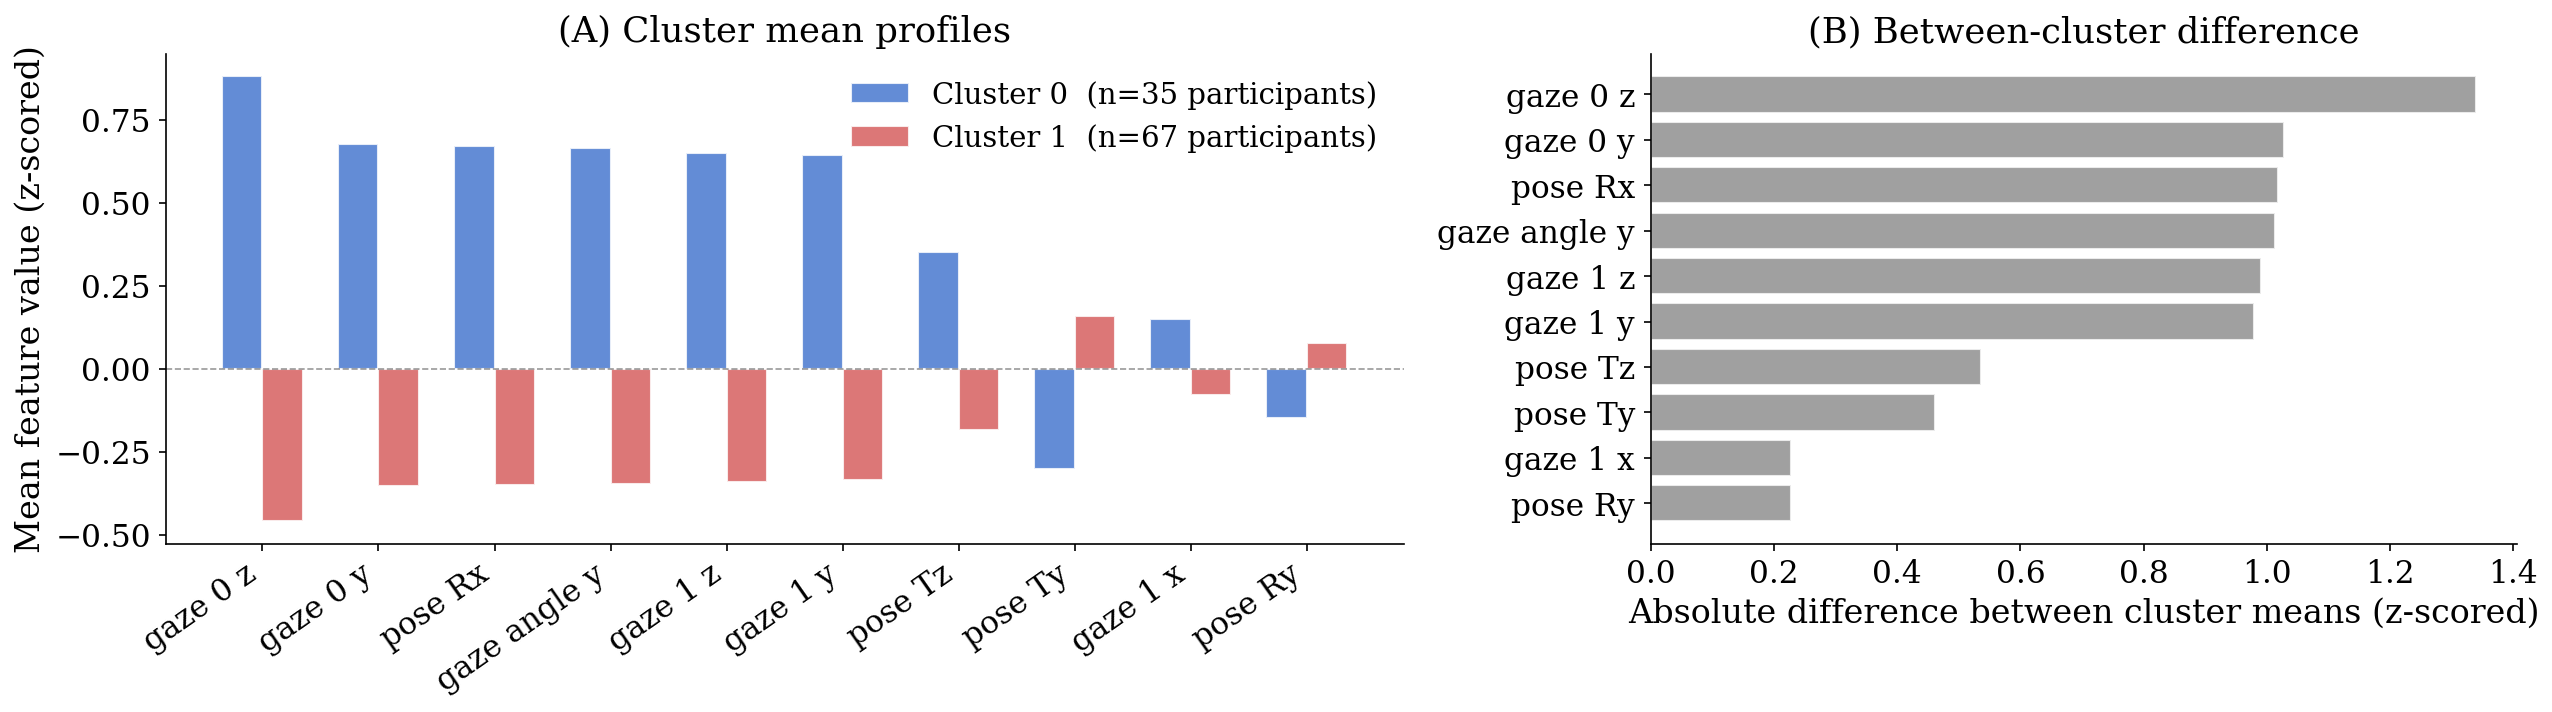

Saved: fig1_cluster_profiles.pdf/.png


In [25]:
from sklearn.preprocessing import StandardScaler

person_features = pd.read_parquet(
    r"C:\Users\super\Desktop\Data Thesis\person_features_clustered.parquet"
)

feature_cols_cluster = [c for c in person_features.columns
                        if c not in ("participant_id", "behavioral_cluster")]

X_raw    = person_features[feature_cols_cluster].fillna(0).values
X_scaled = StandardScaler().fit_transform(X_raw)

person_features_scaled = person_features[["participant_id", "behavioral_cluster"]].copy()
for i, col in enumerate(feature_cols_cluster):
    person_features_scaled[col] = X_scaled[:, i]

gaze_cols_pf = [c for c in feature_cols_cluster if "gaze" in c and c.endswith("_mean")]
pose_cols_pf = [c for c in feature_cols_cluster if "pose" in c and c.endswith("_mean")]
plot_cols    = gaze_cols_pf + pose_cols_pf

cluster_profiles = person_features_scaled.groupby("behavioral_cluster")[plot_cols].mean()

diff         = (cluster_profiles.loc[1] - cluster_profiles.loc[0]).abs()
top_features = diff.sort_values(ascending=False).head(10).index.tolist()

c0_vals = cluster_profiles.loc[0, top_features].values
c1_vals = cluster_profiles.loc[1, top_features].values

def clean_name(col):
    return col.replace("_mean", "").replace("_", " ")

top_labels = [clean_name(f) for f in top_features]

fig, axes = plt.subplots(1, 2, figsize=(17, 5),
                         gridspec_kw={"width_ratios": [2, 1.4]})

ax = axes[0]
x     = np.arange(len(top_features))
width = 0.35

ax.bar(x - width/2, c0_vals, width,
       label="Cluster 0  (n=35 participants)",
       color=CLUSTER_COLORS[0], alpha=0.85, edgecolor="white")
ax.bar(x + width/2, c1_vals, width,
       label="Cluster 1  (n=67 participants)",
       color=CLUSTER_COLORS[1], alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(top_labels, rotation=35, ha="right")
ax.set_ylabel("Mean feature value (z-scored)")
ax.set_title("(A) Cluster mean profiles")
ax.legend(frameon=False)

ax2 = axes[1]
diff_top = diff[top_features].sort_values(ascending=True)

ax2.barh(
    range(len(diff_top)), diff_top.values,
    color="#888888", alpha=0.8, edgecolor="white"
)
ax2.set_yticks(range(len(diff_top)))
ax2.set_yticklabels([clean_name(f) for f in diff_top.index])
ax2.set_xlabel("Absolute difference between cluster means (z-scored)")
ax2.set_title("(B) Between-cluster difference")
ax2.yaxis.set_tick_params(pad=4)

plt.tight_layout()
plt.savefig("fig1_cluster_profiles.pdf", bbox_inches="tight")
plt.savefig("fig1_cluster_profiles.png", bbox_inches="tight")
plt.show()
print("Saved: fig1_cluster_profiles.pdf/.png")

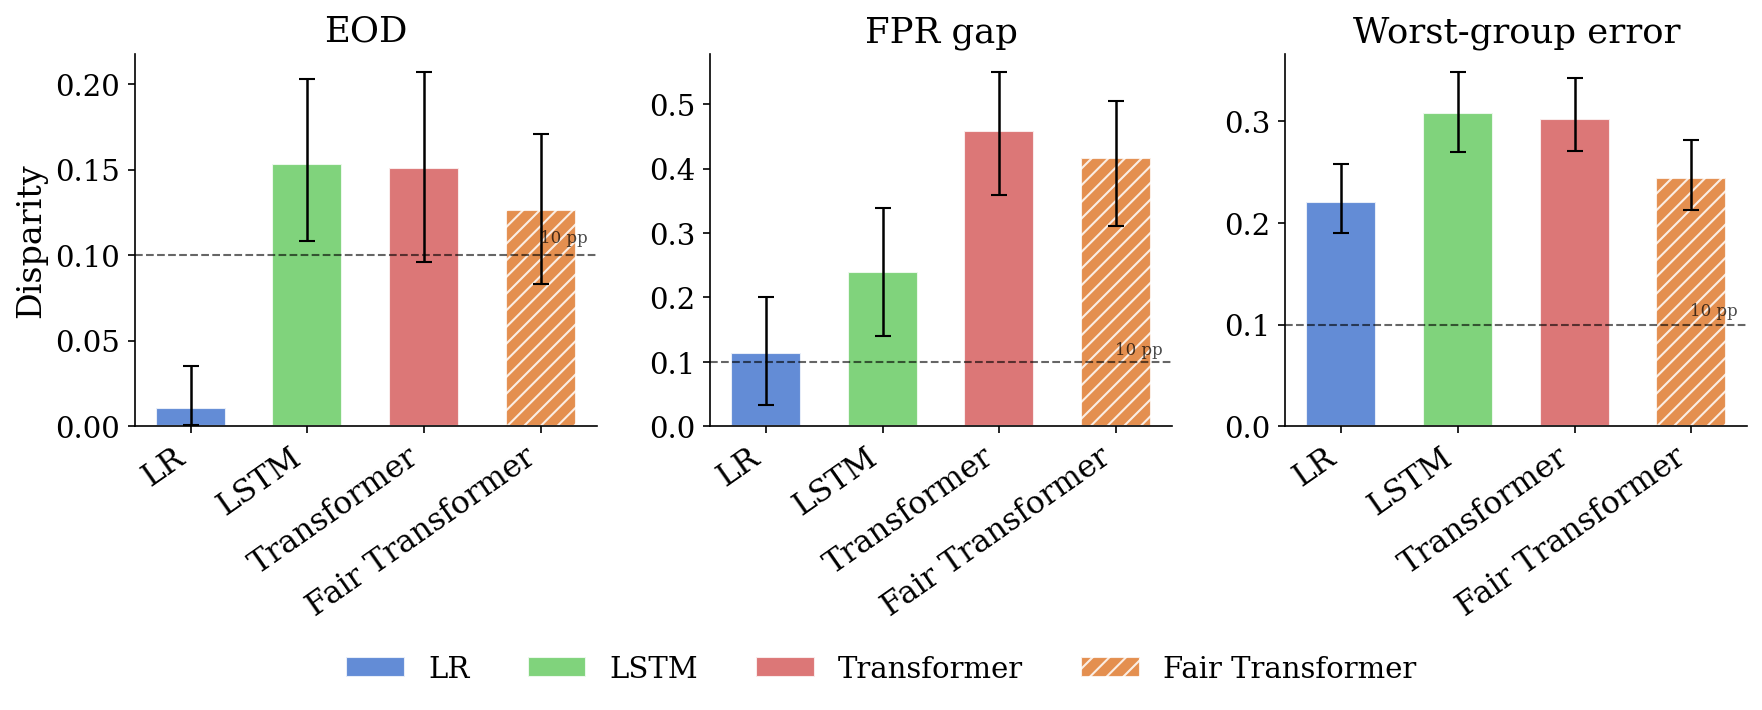

In [31]:
results = {
    "Model": ["LR", "LSTM", "Transformer", "Fair Transformer"],
    "EOD":               [0.0106, 0.1531, 0.1508, 0.1265],
    "FPR gap":           [0.1131, 0.2400, 0.4581, 0.4166],
    "Worst-group error": [0.2209, 0.3081, 0.3023, 0.2442],
    "EOD_lo":            [0.0005, 0.1080, 0.0958, 0.0829],
    "FPR_lo":            [0.0323, 0.1404, 0.3584, 0.3116],
    "WGE_lo":            [0.1903, 0.2696, 0.2707, 0.2127],
    "EOD_hi":            [0.0351, 0.2030, 0.2073, 0.1710],
    "FPR_hi":            [0.2004, 0.3396, 0.5507, 0.5044],
    "WGE_hi":            [0.2578, 0.3491, 0.3430, 0.2813],
}
df = pd.DataFrame(results)

metrics    = ["EOD", "FPR gap", "Worst-group error"]
ci_lo_keys = ["EOD_lo", "FPR_lo", "WGE_lo"]
ci_hi_keys = ["EOD_hi", "FPR_hi", "WGE_hi"]

model_colors = {
    "LR":               "#4878CF",
    "LSTM":             "#6ACC65",
    "Transformer":      "#D65F5F",
    "Fair Transformer": "#E07B30",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=False)

for ax, metric, lo_key, hi_key in zip(axes, metrics, ci_lo_keys, ci_hi_keys):
    for i, row in df.iterrows():
        val   = row[metric]
        lo    = row[lo_key]
        hi    = row[hi_key]
        color = model_colors[row["Model"]]
        hatch = "///" if row["Model"] == "Fair Transformer" else ""
        ax.bar(i, val, color=color, alpha=0.85, edgecolor="white",
               width=0.6, hatch=hatch)
        ax.errorbar(i, val, yerr=[[val - lo], [hi - val]],
                    fmt="none", color="black", capsize=4, linewidth=1.2)

    ax.axhline(0.10, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.text(3.4, 0.105, "10 pp", fontsize=8, va="bottom", ha="right", alpha=0.7)
    ax.set_title(metric)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["Model"], rotation=35, ha="right")
    ax.set_ylim(0, None)
    ax.set_ylabel("Disparity" if ax == axes[0] else "")

legend_handles = [
    mpatches.Patch(facecolor=model_colors["LR"], alpha=0.85,
                   edgecolor="white", label="LR"),
    mpatches.Patch(facecolor=model_colors["LSTM"], alpha=0.85,
                   edgecolor="white", label="LSTM"),
    mpatches.Patch(facecolor=model_colors["Transformer"], alpha=0.85,
                   edgecolor="white", label="Transformer"),
    mpatches.Patch(facecolor=model_colors["Fair Transformer"], alpha=0.85,
                   edgecolor="white", hatch="///", label="Fair Transformer"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("fig2_baseline_disparities.pdf", bbox_inches="tight")
plt.savefig("fig2_baseline_disparities.png", bbox_inches="tight")
plt.show()

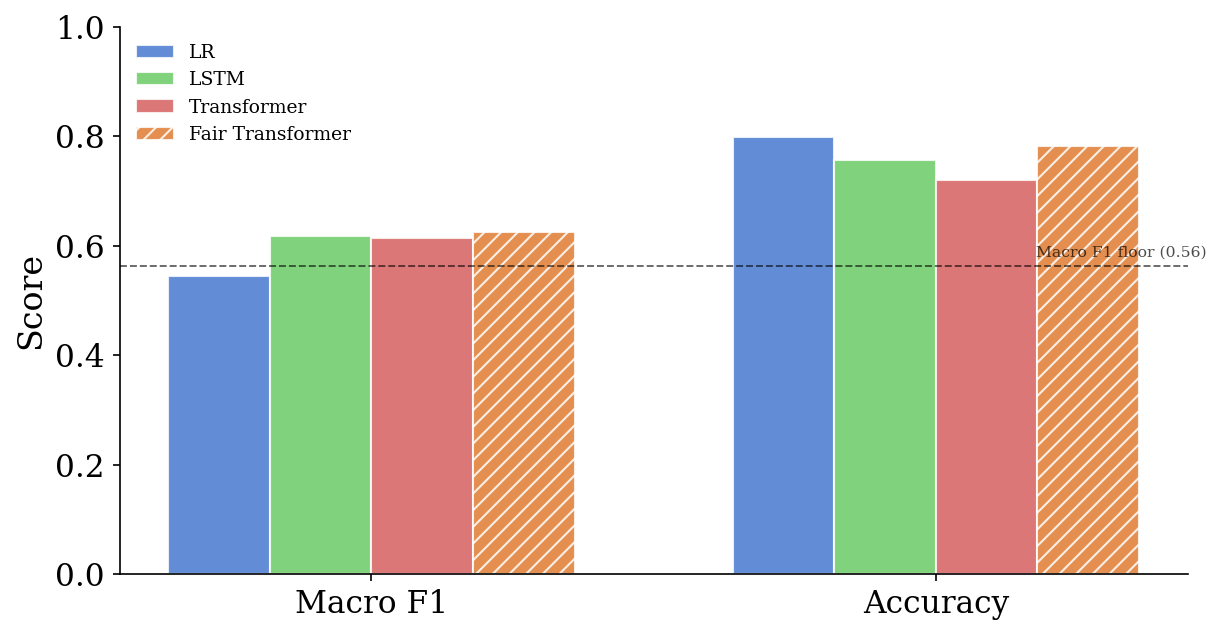

In [27]:
cmp = pd.DataFrame({
    "Metric":           ["Macro F1", "Accuracy"],
    "LR":               [0.5450, 0.7991],
    "LSTM":             [0.6185, 0.7563],
    "Transformer":      [0.6142, 0.7203],
    "Fair Transformer": [0.6248, 0.7817],
})

model_colors_all = {
    "LR":               "#4878CF",
    "LSTM":             "#6ACC65",
    "Transformer":      "#D65F5F",
    "Fair Transformer": "#E07B30",
}
models_ordered = ["LR", "LSTM", "Transformer", "Fair Transformer"]
perf_metrics   = ["Macro F1", "Accuracy"]

fig, ax = plt.subplots(figsize=(8, 5))

x_perf = np.arange(len(perf_metrics))
width  = 0.18

for j, model in enumerate(models_ordered):
    vals  = [cmp.loc[cmp["Metric"] == m, model].values[0] for m in perf_metrics]
    hatch = "///" if model == "Fair Transformer" else ""
    ax.bar(x_perf + j * width, vals, width,
           label=model, color=model_colors_all[model],
           alpha=0.85, edgecolor="white", hatch=hatch)

ax.set_xticks(x_perf + width * 1.5)
ax.set_xticklabels(perf_metrics)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.legend(frameon=False, fontsize=9)
ax.axhline(MACRO_F1_FLOOR, color="black", linestyle="--",
           linewidth=0.9, alpha=0.6)
ax.text(1.75, MACRO_F1_FLOOR + 0.01,
        f"Macro F1 floor ({MACRO_F1_FLOOR:.2f})",
        fontsize=7.5, va="bottom", ha="right", alpha=0.7)

plt.subplots_adjust(left=0.08, right=0.97, top=0.85, bottom=0.12)
plt.savefig("fig3_performance.pdf", bbox_inches="tight")
plt.savefig("fig3_performance.png", bbox_inches="tight")
plt.show()

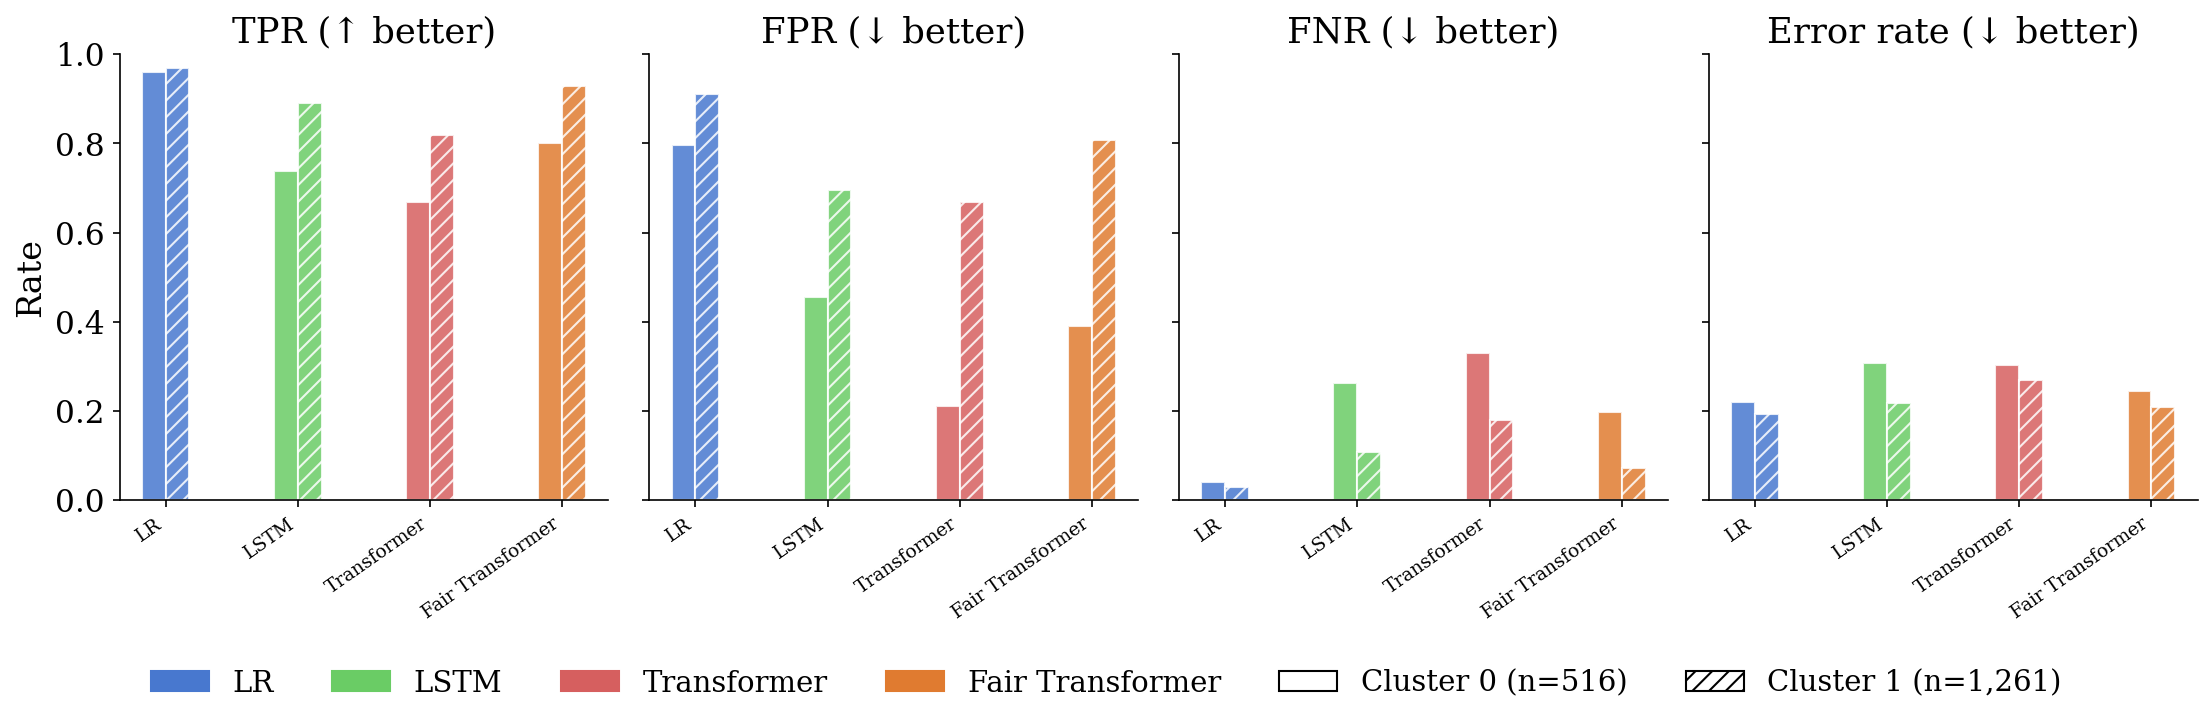

In [29]:
cluster_data = {
    "Cluster": [0, 1, 0, 1, 0, 1, 0, 1],
    "Model":   ["LR", "LR",
                "LSTM", "LSTM",
                "Transformer", "Transformer",
                "Fair Transformer", "Fair Transformer"],
    "TPR":        [0.9593, 0.9698,
                   0.7379, 0.8911,
                   0.6692, 0.8200,
                   0.8015, 0.9280],
    "FPR":        [0.7967, 0.9099,
                   0.4553, 0.6953,
                   0.2114, 0.6695,
                   0.3902, 0.8069],
    "FNR":        [0.0407, 0.0302,
                   0.2621, 0.1089,
                   0.3308, 0.1800,
                   0.1985, 0.0720],
    "Error rate": [0.2209, 0.1927,
                   0.3081, 0.2173,
                   0.3023, 0.2704,
                   0.2442, 0.2078],
}
cd = pd.DataFrame(cluster_data)

metrics_to_plot = ["TPR", "FPR", "FNR", "Error rate"]
metric_labels   = ["TPR (↑ better)", "FPR (↓ better)",
                   "FNR (↓ better)", "Error rate (↓ better)"]

models_ordered = ["LR", "LSTM", "Transformer", "Fair Transformer"]
cluster_hatch  = {0: "", 1: "///"}
width          = 0.18
x              = np.arange(len(models_ordered))

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5), sharey=True)

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    for ci, cluster in enumerate([0, 1]):
        vals = [
            cd.loc[(cd["Model"] == m) & (cd["Cluster"] == cluster), metric].values[0]
            for m in models_ordered
        ]
        bars = ax.bar(
            x + ci * width, vals, width,
            color=[model_colors_all[m] for m in models_ordered],
            alpha=0.85, edgecolor="white",
            hatch=cluster_hatch[cluster],
            label=f"Cluster {cluster}" if ax == axes[0] else "_nolegend_"
        )

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(models_ordered, rotation=35, ha="right", fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_title(label)
    if ax == axes[0]:
        ax.set_ylabel("Rate")

# Legend: model colors + cluster hatch
legend_handles = [
    mpatches.Patch(color=model_colors_all[m], label=m)
    for m in models_ordered
] + [
    mpatches.Patch(facecolor="white", edgecolor="black",
                   label="Cluster 0 (n=516)",   hatch=""),
    mpatches.Patch(facecolor="white", edgecolor="black",
                   label="Cluster 1 (n=1,261)", hatch="///"),
]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=6, frameon=False, bbox_to_anchor=(0.5, -0.10))

plt.tight_layout()
plt.savefig("fig4_per_cluster_errors.pdf", bbox_inches="tight")
plt.savefig("fig4_per_cluster_errors.png", bbox_inches="tight")
plt.show()